# Regime-Sliced Performance for the Section 16.4 ETF Baseline

**Docker image**: `ml4t`

## Purpose

Diagnose whether the fixed ETF momentum baseline behaves differently across pre-specified,
point-in-time volatility and trend states.

## Learning objectives

- Label every day of a backtest with the market conditions that were observable *before* that
  day's return began, and say why a label built from the day's own return would be worthless.
- Split a single track record four ways and compute return, risk and drawdown inside each slice.
- Read a conditional statistic against the number of days it was computed from, and say which
  slices are too thin to carry an estimate.
- Attribute a peak-to-trough loss across conditions exactly, using the one transformation of
  returns that adds.

**Book reference**: Chapter 16, Section 16.6 (diagnosing economic value).

**Prerequisites**: `01_backtest_first_principles`, which builds the strategy this notebook slices.

Everything here is descriptive. No period is held out, nothing is selected, and a state that
looks good is a statement about when returns happened rather than about why.

## 1. Setup and protocol

The baseline uses month-end ETF closes and the end-of-day Treasury spread to form targets. The
target is shifted to the next trading day and filled at that day's open. End-of-day equity is
marked at the close. The diagnostic state for a return on day $t$ is the state known at the close
of day $t-1$.

In [1]:
"""Point-in-time regime diagnostics for the Section 16.4 ETF baseline."""

import hashlib

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import sharpe_ratio

from data import load_etfs, load_macro
from utils import ML4T_DATA_PATH
from utils.style import COLORS, add_message_title, format_pct_axis, show_with_alt

In [2]:
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
MOMENTUM_LOOKBACK = 126
VOL_LOOKBACK = 60
TREND_LOOKBACK = 126
TOP_N = 3
YIELD_CURVE_THRESHOLD = 0.005
INITIAL_CASH = 100_000.0
FEE_RATE = 0.0005
PERIODS_PER_YEAR = 252

In [3]:
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "TLT", "GLD", "VNQ", "DBC"]
DEFENSIVE_MIX = {"AGG": 0.60, "TLT": 0.40}

### What each setting decides

The first block reproduces `01_backtest_first_principles` exactly and is explained there. The
three lookbacks worth naming here are the ones that build the market states.

**Volatility lookback.** How much recent history the realized-volatility estimate averages. Short
enough that it reacts within a market episode, long enough that a single bad week does not define
the state. Roughly a quarter of trading days.

**Trend lookback.** The window over which the index's total return is measured. It is set to the
same length as the strategy's own momentum lookback, so that "trending up" means the same span of
history the strategy is ranking on.

**Why medians rather than fixed levels.** Both states are defined against the median of that
statistic's own past, not against a number chosen in advance. A fixed volatility threshold would
put almost every day of 2017 in one state and almost every day of 2020 in the other, which
measures the decade rather than the condition. An expanding past median splits each statistic
against its own history and uses nothing from the future.

In [4]:
print(f"Strategy:     top {TOP_N} of {len(ETF_SYMBOLS)} ETFs on {MOMENTUM_LOOKBACK}-session")
print("              risk-adjusted momentum, rebalanced monthly at the next open")
print(f"Defensive:    {', '.join(f'{w:.0%} {s}' for s, w in DEFENSIVE_MIX.items())}")
print(f"Risk-on when: the 10Y-2Y spread exceeds {YIELD_CURVE_THRESHOLD:.2%}")
print(f"Costs:        {FEE_RATE * 10_000:.0f} bps per dollar traded")
print(f"States:       volatility over {VOL_LOOKBACK} sessions, trend over {TREND_LOOKBACK}")
print(f"Sample:       {START_DATE} to {END_DATE}")

Strategy:     top 3 of 10 ETFs on 126-session
              risk-adjusted momentum, rebalanced monthly at the next open
Defensive:    60% AGG, 40% TLT
Risk-on when: the 10Y-2Y spread exceeds 0.50%
Costs:        5 bps per dollar traded
States:       volatility over 60 sessions, trend over 126
Sample:       2010-01-01 to 2024-01-01


These ten funds were picked because they exist today and are widely held, which is a reasonable
teaching universe and an unreasonable investment universe: a fund that closed during the sample
is not in it, and a fund that was not yet launched in 2010 would have been. Every figure below
describes these ten survivors.

## 2. Load and validate the market panel

The canonical loader returns Polars data keyed by `symbol` and `timestamp`. Opens determine fills;
closes determine signals and end-of-day value. Forward filling only carries the last observation
forward, and the complete-case filter removes any rows before all funds have valid prices.

In [5]:
etf_long = load_etfs(symbols=ETF_SYMBOLS, start_date=START_DATE, end_date=END_DATE)
duplicate_keys = etf_long.group_by(["symbol", "timestamp"]).len().filter(pl.col("len") > 1).height
assert duplicate_keys == 0, f"Found {duplicate_keys} duplicate ETF keys"

open_wide = etf_long.pivot(on="symbol", index="timestamp", values="open").sort("timestamp")
close_wide = etf_long.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")
assert all(symbol in open_wide.columns for symbol in ETF_SYMBOLS)
assert all(symbol in close_wide.columns for symbol in ETF_SYMBOLS)

In [6]:
price_panel = (
    open_wide.select(
        "timestamp",
        *(pl.col(symbol).alias(f"{symbol}_open") for symbol in ETF_SYMBOLS),
    )
    .join(
        close_wide.select(
            "timestamp",
            *(pl.col(symbol).alias(f"{symbol}_close") for symbol in ETF_SYMBOLS),
        ),
        on="timestamp",
        how="inner",
    )
    .with_columns(pl.exclude("timestamp").forward_fill())
    .drop_nulls()
    .sort("timestamp")
)

dates = price_panel["timestamp"].to_list()
open_prices = price_panel.select(f"{symbol}_open" for symbol in ETF_SYMBOLS).to_numpy()
close_prices = price_panel.select(f"{symbol}_close" for symbol in ETF_SYMBOLS).to_numpy()
assert np.isfinite(open_prices).all() and np.isfinite(close_prices).all()
assert (open_prices > 0).all() and (close_prices > 0).all()
print(f"Loaded {len(dates):,} complete daily bars for {len(ETF_SYMBOLS)} ETFs")
print(f"Date range: {dates[0]} to {dates[-1]}")

Loaded 3,522 complete daily bars for 10 ETFs
Date range: 2010-01-04 to 2023-12-29


## 3. Reproduce the fixed baseline

A backward as-of join carries only Treasury observations dated on or before each ETF date. The
local FRED file is a current snapshot, not an ALFRED vintage panel, so the calendar alignment is
point-in-time but the historical values may include later revisions.

In [7]:
macro_frame = load_macro(start_date=START_DATE, end_date=END_DATE)
fred_path = ML4T_DATA_PATH / "macro" / "fred_macro.parquet"
fred_coverage_end = pl.read_parquet(fred_path, columns=["date"])["date"].max()
fred_hash = hashlib.sha256(fred_path.read_bytes()).hexdigest()[:12]

print(f"FRED snapshot covers observations through {fred_coverage_end}")
print(f"FRED snapshot content hash: sha256:{fred_hash}")

yield_curve = macro_frame.select(
    "timestamp", (pl.col("YIELD_CURVE_SLOPE") / 100).alias("slope")
).drop_nulls()

FRED snapshot covers observations through 2025-12-31
FRED snapshot content hash: sha256:fad73c1ee0c0


The row count below only establishes that the Treasury series had started by the first ETF
date. A backward as-of join matches every later date to something, so a stretch where the
Fed published nothing would be carried across rather than reported. The measurement that
does see such a gap is the age of the observation each date matched, against a tolerance
declared before the result is printed.

In [8]:
MAX_SLOPE_AGE_DAYS = 4

regime_panel = (
    price_panel.select("timestamp")
    .join_asof(
        yield_curve.sort("timestamp").with_columns(pl.col("timestamp").alias("slope_asof")),
        on="timestamp",
        strategy="backward",
    )
    .drop_nulls()
)
assert regime_panel.height == price_panel.height, (
    "Yield-curve history begins after the ETF panel does"
)

slope_age_days = regime_panel.select(
    (pl.col("timestamp") - pl.col("slope_asof")).dt.total_days()
).to_series()
print(
    f"Yield-curve observation age when read: median {slope_age_days.median():.0f}d, "
    f"max {slope_age_days.max()}d (tolerance {MAX_SLOPE_AGE_DAYS}d)"
)
assert slope_age_days.max() <= MAX_SLOPE_AGE_DAYS, (
    f"Yield curve went {slope_age_days.max()} days without a publication"
)

yield_curve_slope = regime_panel["slope"].to_numpy()
allocation_risk_on = yield_curve_slope > YIELD_CURVE_THRESHOLD

close_frame = price_panel.select(
    "timestamp", *(pl.col(f"{symbol}_close").alias(symbol) for symbol in ETF_SYMBOLS)
)

Yield-curve observation age when read: median 0d, max 0d (tolerance 4d)


Each score uses closes through the current date. Cross-sectional ranking happens independently
at each month-end, so no full-sample estimate enters the target selection.

In [9]:
momentum_frame = close_frame.select(
    "timestamp",
    *(
        (
            (pl.col(symbol) / pl.col(symbol).shift(MOMENTUM_LOOKBACK) - 1)
            / (
                (pl.col(symbol) / pl.col(symbol).shift(1) - 1).rolling_std(MOMENTUM_LOOKBACK)
                * np.sqrt(PERIODS_PER_YEAR)
            )
        ).alias(symbol)
        for symbol in ETF_SYMBOLS
    ),
)
momentum_scores = momentum_frame.select(ETF_SYMBOLS).to_numpy()
first_valid = int(np.flatnonzero(np.isfinite(momentum_scores).sum(axis=1) >= TOP_N)[0])

month_end_signal = np.zeros(len(dates), dtype=bool)
for index in range(len(dates) - 1):
    month_end_signal[index] = (dates[index].year, dates[index].month) != (
        dates[index + 1].year,
        dates[index + 1].month,
    )
month_end_signal[-1] = True

In [10]:
defensive_weights = np.zeros(len(ETF_SYMBOLS))
for symbol, weight in DEFENSIVE_MIX.items():
    defensive_weights[ETF_SYMBOLS.index(symbol)] = weight

signal_weights = np.zeros_like(close_prices)
current_target = defensive_weights.copy()
for index in range(len(dates)):
    if month_end_signal[index]:
        current_target = defensive_weights.copy()
        valid = np.flatnonzero(np.isfinite(momentum_scores[index]))
        if index >= first_valid and allocation_risk_on[index] and len(valid) >= TOP_N:
            selected = valid[np.argsort(momentum_scores[index, valid])[-TOP_N:]]
            current_target = np.zeros(len(ETF_SYMBOLS))
            current_target[selected] = 1 / TOP_N
    signal_weights[index] = current_target

execution_weights = np.vstack([defensive_weights, signal_weights[:-1]])
rebalance_at_open = np.r_[True, month_end_signal[:-1]]
assert np.allclose(execution_weights.sum(axis=1), 1.0)

The simulator sells first, deducts fees, and scales purchases to available cash. This event order
prevents fees from creating an unreported negative-cash loan.

In [11]:
def simulate_portfolio(
    opens: np.ndarray,
    closes: np.ndarray,
    target_weights: np.ndarray,
    rebalance_mask: np.ndarray,
    initial_cash: float,
    fee_rate: float,
) -> dict[str, np.ndarray]:
    """Simulate long-only next-open rebalancing with proportional fees."""
    holdings = np.zeros(closes.shape[1])
    cash = initial_cash
    equity = np.zeros(len(closes))
    cash_path = np.zeros(len(closes))
    for index in range(len(closes)):
        if rebalance_mask[index]:
            open_values = holdings * opens[index]
            target_values = target_weights[index] * (cash + open_values.sum())
            sells = np.maximum(open_values - target_values, 0.0)
            holdings -= sells / opens[index]
            cash += sells.sum() * (1 - fee_rate)
            requested = np.maximum(target_values - holdings * opens[index], 0.0)
            required = requested.sum() * (1 + fee_rate)
            scale = min(1.0, cash / required) if required > 0 else 0.0
            buys = requested * scale
            holdings += buys / opens[index]
            cash -= buys.sum() * (1 + fee_rate)
        if cash < -1e-8:
            raise RuntimeError(f"Cash constraint violated at bar {index}: {cash}")
        cash = max(cash, 0.0)
        cash_path[index] = cash
        equity[index] = cash + float(holdings @ closes[index])
    return {"equity": equity, "cash": cash_path}

In [12]:
baseline = simulate_portfolio(
    open_prices,
    close_prices,
    execution_weights,
    rebalance_at_open,
    INITIAL_CASH,
    FEE_RATE,
)
baseline_returns = (
    np.diff(np.r_[INITIAL_CASH, baseline["equity"]]) / np.r_[INITIAL_CASH, baseline["equity"]][:-1]
)
assert baseline["cash"].min() >= 0

baseline_total_return = float(np.prod(1 + baseline_returns) - 1)
baseline_cagr = float((1 + baseline_total_return) ** (PERIODS_PER_YEAR / len(dates)) - 1)
baseline_sharpe = float(sharpe_ratio(baseline_returns, periods_per_year=PERIODS_PER_YEAR))
baseline_growth = np.cumprod(1 + baseline_returns)
baseline_max_drawdown = float(
    np.min(baseline_growth / np.maximum.accumulate(np.r_[1.0, baseline_growth])[1:] - 1)
)

print(f"Baseline CAGR:         {baseline_cagr:.2%}")
print(f"Baseline Sharpe:       {baseline_sharpe:.2f}")
print(f"Baseline max drawdown: {baseline_max_drawdown:.1%}")
print(f"Next-open rebalances:  {rebalance_at_open.sum()}")

Baseline CAGR:         8.09%
Baseline Sharpe:       0.74
Baseline max drawdown: -31.3%
Next-open rebalances:  168


## 4. Build point-in-time volatility and trend states

Let $\sigma_t$ be trailing realized volatility and $\rho_t$ be trailing total return. Each is
compared with the expanding median of its own observations strictly before $t$:

$$
v_t = \mathbf{1}\!\left[\sigma_t \geq \operatorname{median}(\sigma_s:s<t)\right],\qquad
u_t = \mathbf{1}\!\left[\rho_t > \operatorname{median}(\rho_s:s<t)\right].
$$

The resulting state is shifted one bar before it is joined to strategy returns.

In [13]:
def expanding_past_median(values: np.ndarray) -> np.ndarray:
    """Return the median of finite observations strictly before each row."""
    result = np.full(len(values), np.nan)
    observed: list[float] = []
    for index, value in enumerate(values):
        if observed:
            result[index] = float(np.median(observed))
        if np.isfinite(value):
            observed.append(float(value))
    return result

In [14]:
spy_close = close_frame["SPY"].to_numpy()
spy_return = np.r_[np.nan, np.diff(spy_close) / spy_close[:-1]]
realized_vol = pl.Series(spy_return).rolling_std(VOL_LOOKBACK).to_numpy() * np.sqrt(
    PERIODS_PER_YEAR
)
trend_return = np.full(len(spy_close), np.nan)
trend_return[TREND_LOOKBACK:] = spy_close[TREND_LOOKBACK:] / spy_close[:-TREND_LOOKBACK] - 1

past_vol_median = expanding_past_median(realized_vol)
past_trend_median = expanding_past_median(trend_return)
valid_state = np.isfinite(realized_vol) & np.isfinite(trend_return)
valid_state &= np.isfinite(past_vol_median) & np.isfinite(past_trend_median)

raw_vol_state = np.where(realized_vol < past_vol_median, "Low", "High")
raw_trend_state = np.where(trend_return > past_trend_median, "Up", "Down")

The two binary states map to the chapter's pre-specified four-state taxonomy.

In [15]:
def combine_state(volatility: str, trend: str) -> str:
    """Map the two binary diagnostics to the pre-specified four-state taxonomy."""
    return {
        ("Low", "Up"): "Risk-on",
        ("High", "Up"): "Caution",
        ("High", "Down"): "Crisis",
        ("Low", "Down"): "Recovery",
    }[(volatility, trend)]

In [16]:
raw_regime = np.full(len(dates), "Warmup", dtype=object)
raw_regime[valid_state] = [
    combine_state(volatility, trend)
    for volatility, trend in zip(
        raw_vol_state[valid_state], raw_trend_state[valid_state], strict=True
    )
]
return_regime = np.concatenate((np.array(["Warmup"], dtype=object), raw_regime[:-1]))

## 5. Measure conditional performance

Conditional CAGR annualizes the compounded subsequence of days assigned to a state. Conditional
maximum drawdown does the same, so it is a non-contiguous diagnostic path rather than a calendar
episode. Sharpe uses mean periodic return divided by periodic volatility, annualized by
$\sqrt{252}$.

In [17]:
def summarize_returns(values: np.ndarray) -> dict[str, float]:
    """Compute conditional growth, volatility, Sharpe, and path drawdown."""
    total_return = float(np.prod(1 + values) - 1)
    cagr = float((1 + total_return) ** (PERIODS_PER_YEAR / len(values)) - 1)
    volatility = float(np.std(values, ddof=1) * np.sqrt(PERIODS_PER_YEAR))
    growth = np.cumprod(1 + values)
    running_peak = np.maximum.accumulate(np.r_[1.0, growth])[1:]
    maximum_drawdown = float(np.min(growth / running_peak - 1))
    return {
        "cagr": cagr,
        "volatility": volatility,
        "sharpe": float(sharpe_ratio(values, periods_per_year=PERIODS_PER_YEAR)),
        "maximum_drawdown": maximum_drawdown,
    }

In [18]:
states = ["Risk-on", "Caution", "Crisis", "Recovery"]
active_mask = return_regime != "Warmup"
active_days = int(active_mask.sum())
rows = []
for state in states:
    state_mask = return_regime == state
    statistics = summarize_returns(baseline_returns[state_mask])
    rows.append(
        {
            "regime": state,
            "days": int(state_mask.sum()),
            "share": float(state_mask.sum() / active_days),
            **statistics,
        }
    )

overall = summarize_returns(baseline_returns[active_mask])
overall_row = {"regime": "All active days", "days": active_days, "share": 1.0, **overall}
regime_summary = pl.DataFrame(rows)
regime_summary_with_total = pl.DataFrame([*rows, overall_row])
regime_summary_with_total

regime,days,share,cagr,volatility,sharpe,maximum_drawdown
str,i64,f64,f64,f64,f64,f64
"""Risk-on""",1227,0.36152,0.01187,0.107312,0.163795,-0.177114
"""Caution""",453,0.133471,0.182874,0.139578,1.273474,-0.137066
"""Crisis""",1145,0.33736,0.071818,0.118424,0.64494,-0.238598
"""Recovery""",569,0.167649,0.156677,0.098936,1.520988,-0.105686
"""All active days""",3394,1.0,0.077326,0.114618,0.707329,-0.313429


The last row is every active day pooled, and it is the row the four above have to be read
against. A conditional Sharpe means nothing on its own: what carries information is whether a
state's figure is far from the pooled one, and whether it rests on enough days to be far from it
for a reason. The `days` and `share` columns are what decide the second question, and the
thinnest state is the one to distrust first.

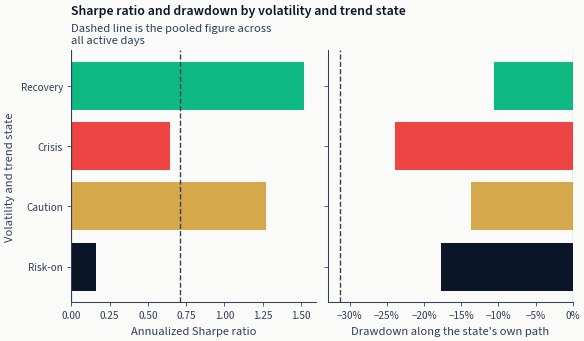

In [19]:
fig, axes = plt.subplots(1, 2)
state_labels = regime_summary["regime"].to_list()
state_colors = [COLORS["blue"], COLORS["amber"], COLORS["negative"], COLORS["positive"]]

axes[0].barh(state_labels, regime_summary["sharpe"], color=state_colors)
axes[0].axvline(overall["sharpe"], color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[0].axvline(0, color=COLORS["neutral"], linewidth=0.8)
axes[0].set_xlabel("Annualized Sharpe ratio")
axes[0].set_ylabel("Volatility and trend state")

axes[1].barh(state_labels, regime_summary["maximum_drawdown"], color=state_colors)
axes[1].axvline(overall["maximum_drawdown"], color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[1].axvline(0, color=COLORS["neutral"], linewidth=0.8)
axes[1].set_xlabel("Drawdown along the state's own path")
axes[1].tick_params(labelleft=False)
format_pct_axis(axes[1], axis="x")

add_message_title(
    axes[0],
    "Sharpe ratio and drawdown by volatility and trend state",
    subtitle="Dashed line is the pooled figure across all active days",
)
show_with_alt(
    fig,
    (
        "Two horizontal bar panels sharing a state axis, one bar per volatility and trend "
        "state, each state in its own colour, with a dashed line marking the pooled figure "
        "across all active days. The left panel is the annualized Sharpe of each state's "
        "days. The right is the drawdown of a path built by compounding only that state's "
        "days in order, so it is the fall a portfolio would have taken holding through those "
        "days alone rather than the fall it lived through between them. The pooled line is "
        "drawn on both so each state can be read against the aggregate it is part of."
    ),
)

The dashed line on each panel is the pooled figure, so the length of a bar past it is what the
condition is worth. Two cautions before reading anything into the spread.

The drawdown panel measures a path that never existed. A state's days are scattered through the
sample rather than consecutive, so compounding only those days produces a synthetic equity curve
that no account followed. It is a fair way to compare states with each other and a bad way to
state what an investor would have lived through, which section 7 handles instead.

And a state that covers a small share of the sample carries a wide error around every figure in
its row, whatever the bar looks like. Read the `days` column before the bar.

## 6. Are the bad days worse in a crisis?

Value at Risk is a threshold: the loss that the worst one day in twenty exceeds. Conditional
Value at Risk is the average of those days, which is the more useful number because it says how
bad the tail is rather than only where it starts.

The obvious expectation is that a strategy's tail is fatter on crisis days. Whether it is depends
on what the strategy is holding then, and this one rotates into bonds when the yield curve
flattens. The same estimator is applied to the pooled active sample and to the Crisis slice, and
the two histograms are drawn on shared bins so their shapes are comparable rather than each
rescaled to its own range.

In [20]:
overall_returns = baseline_returns[active_mask]
crisis_returns = baseline_returns[return_regime == "Crisis"]
overall_var_95 = float(np.quantile(overall_returns, 0.05))
crisis_var_95 = float(np.quantile(crisis_returns, 0.05))
overall_cvar_95 = float(overall_returns[overall_returns <= overall_var_95].mean())
crisis_cvar_95 = float(crisis_returns[crisis_returns <= crisis_var_95].mean())

shared_bins = np.linspace(
    min(overall_returns.min(), crisis_returns.min()),
    max(overall_returns.max(), crisis_returns.max()),
    60,
)

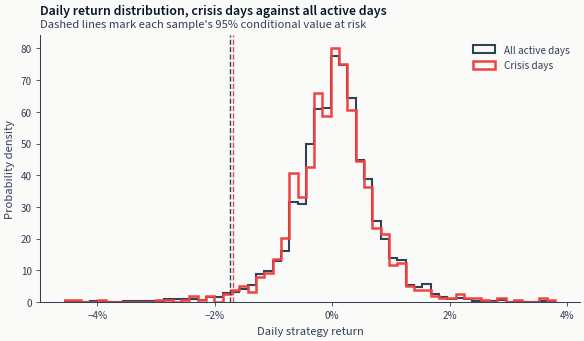

In [21]:
fig, ax = plt.subplots()
ax.hist(
    overall_returns,
    bins=shared_bins,
    density=True,
    histtype="step",
    linewidth=1.5,
    color=COLORS["neutral"],
    label="All active days",
)
ax.hist(
    crisis_returns,
    bins=shared_bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color=COLORS["negative"],
    label="Crisis days",
)
ax.axvline(overall_cvar_95, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax.axvline(crisis_cvar_95, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.set_xlabel("Daily strategy return")
ax.set_ylabel("Probability density")
format_pct_axis(ax, axis="x")
ax.legend(frameon=False)
add_message_title(
    ax,
    "Daily return distribution, crisis days against all active days",
    subtitle="Dashed lines mark each sample's 95% conditional value at risk",
)
show_with_alt(
    fig,
    (
        "Two step histograms of daily strategy return on a shared axis, all active days "
        "outlined in navy and crisis days in red, with each sample's 95 percent conditional "
        "value at risk marked by a dashed vertical line in its own colour. Crisis days are a "
        "subset of the active days rather than a disjoint sample, so the red distribution is "
        "drawn from observations the navy one also contains."
    ),
)

In [22]:
print(f"Crisis days:                 {len(crisis_returns):,}")
print(f"95% CVaR, crisis days:       {crisis_cvar_95:.2%}")
print(f"95% CVaR, all active days:   {overall_cvar_95:.2%}")
print(f"Difference:                  {(crisis_cvar_95 - overall_cvar_95) * 10_000:.0f} bps")

Crisis days:                 1,145
95% CVaR, crisis days:       -1.69%
95% CVaR, all active days:   -1.75%
Difference:                  5 bps


The two are effectively the same, and the sign is the opposite of what the section set out to
find: the crisis tail is marginally *shallower*. That is a result, not a failed measurement, and
the mechanism is in the strategy rather than in the market. The rule holds bonds whenever the
yield curve is flat, and a flat curve is common in exactly the conditions this diagnostic labels
Crisis. The strategy's worst days are therefore mostly not crisis days; they are days when it was
holding equities and the label had not caught up.

The useful reading is about the diagnostic, not the strategy. A state definition built from the
market says nothing about what a strategy was holding at the time, and a strategy that changes
exposure across states will not show its risk where the state labels say it should. To find where
this strategy's losses actually accumulated, the slice has to follow the losses - which is what
the next section does.

## 7. Attribute the worst calendar drawdown

Simple return sums are not additive through compounding. Log returns are, so summing
$\log(1+r_t)$ by state gives an exact additive attribution of the peak-to-trough growth ratio.

In [23]:
running_peak = np.maximum.accumulate(np.r_[1.0, baseline_growth])[1:]
drawdown = baseline_growth / running_peak - 1
trough_index = int(np.argmin(drawdown))
peak_index = int(np.argmax(baseline_growth[: trough_index + 1]))
episode_mask = np.zeros(len(dates), dtype=bool)
episode_mask[peak_index + 1 : trough_index + 1] = True

episode_frame = pl.DataFrame(
    {
        "regime": return_regime[episode_mask],
        "log_return": np.log1p(baseline_returns[episode_mask]),
    }
)
attribution = (
    episode_frame.group_by("regime")
    .agg(pl.len().alias("days"), pl.col("log_return").sum().alias("log_return_contribution"))
    .sort("log_return_contribution")
)
assert np.isclose(
    attribution["log_return_contribution"].sum(),
    np.log(baseline_growth[trough_index] / baseline_growth[peak_index]),
)

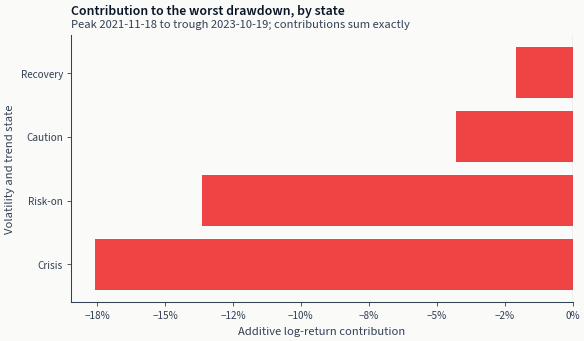

In [24]:
fig, ax = plt.subplots()
colors = [
    COLORS["negative"] if value < 0 else COLORS["positive"]
    for value in attribution["log_return_contribution"]
]
ax.barh(attribution["regime"], attribution["log_return_contribution"], color=colors)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel("Additive log-return contribution")
ax.set_ylabel("Volatility and trend state")
format_pct_axis(ax, axis="x")
add_message_title(
    ax,
    "Contribution to the worst drawdown, by state",
    subtitle=f"Peak {dates[peak_index]} to trough {dates[trough_index]}; contributions sum exactly",
)
show_with_alt(
    fig,
    (
        "Horizontal bar chart of each state's additive contribution to the worst drawdown, in "
        "log return, one bar per state. Log returns are used because they add across "
        "sessions, which is what allows the drawdown to be decomposed by state at all; the "
        "same decomposition in simple returns would not sum to the total."
    ),
)

In [25]:
print(f"Worst drawdown: {dates[peak_index]} to {dates[trough_index]}, {drawdown[trough_index]:.1%}")
print(f"Sessions in the episode: {int(episode_mask.sum()):,}")

Worst drawdown: 2021-11-18 to 2023-10-19, -31.3%
Sessions in the episode: 481


Because log returns add, each bar is exactly the share of the peak-to-trough loss that
accumulated while the market was in that condition - the assertion above checks that they sum to
the episode's own log growth ratio, with nothing left over. A bar is not evidence that the
condition caused the loss. Two of these states are more common than the others, so a longer bar
can simply be more days.

## Key takeaways

1. **A state label has to be readable before the return it labels.** The volatility and trend
   figures for day $t$ use closes through $t-1$, both are compared against the median of their
   own past rather than of the whole sample, and the resulting label is shifted one bar before it
   is joined. Any of those three omitted, and a state would be partly defined by the return it is
   supposed to explain, which guarantees a strong-looking result that means nothing.
2. **Read a conditional statistic next to its sample size, always.** Splitting one track record
   four ways divides the evidence four ways too, and the spread between the highest and lowest
   slice grows as the slices get thinner whether or not anything is happening.
3. **A drawdown computed inside a slice is a path nobody experienced.** Compounding a state's
   scattered days produces a curve no account followed. It compares states fairly and describes
   an investor's experience badly.
4. **Market conditions do not describe a strategy's exposure.** A rule that moves into bonds when
   the curve flattens has few equity-crisis days left to lose money on, which is why the crisis
   tail here is no worse than an ordinary one. Slicing by market state answers "when did the
   market do this", not "when did this strategy lose money".
5. **Attribute compounded losses with log returns.** Simple returns do not add, so summing them
   by state gives a decomposition that does not reconcile with the loss it decomposes. Log returns
   do add, exactly, which is what makes the assertion in section 7 possible.

### Known limitations

- Four states over one sample, and every slice's statistics are point estimates with no interval
  around them. The notebook shows the day counts rather than a confidence band because the
  overlapping-window dependence in the state definitions makes a naive interval wrong.
- The universe is ten funds that exist today. Nothing here is free of survivorship bias.
- The states are built from one index, SPY. A different proxy for market conditions would relabel
  days and move every conditional figure.
- The macro series is a present-day snapshot rather than a record of what was published at the
  time, so a spread used on a historical date may since have been revised.

**Next:** `11_sharpe_ratio_inference` puts an interval around the aggregate Sharpe this notebook
takes as a point, and `14_cost_sensitivity` re-runs the baseline across fee assumptions.